### Question 1
Program the Heavyball Method

In [453]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [260]:
f = lambda x,y: 100*(y-x**2)**2+(1-x)**2
Df = lambda x,y: np.array([400*x**3-400*x*y-2+2*x,
                           200*y - 200*x**2])
D2g = lambda x,y: np.array([[1200*x**2 - 400*y +2, -400*x],
                            [-400*x, 200]])

In [261]:
from matplotlib.colors import LogNorm  # useful for visualizing this function

def plot_path(path, func, title, window=[-4.5,4.5,-4.5,4.5], contours=np.logspace(-2,6,100), skip=1):
    '''Plots path defined in (N,2) array "path" on a contour plot of "func" in window "window"'''
    plt.figure(figsize=(5,5),dpi=150)
    X = np.linspace(window[0],window[1],300)
    Y = np.linspace(window[2],window[3],300)
    Xmesh, Ymesh = np.meshgrid(X,Y)
    Z = func(Xmesh,Ymesh)
    CS = plt.contourf(Xmesh, Ymesh, Z, contours, cmap='jet', norm = LogNorm())
    # contourf fills the colors. blue is lower value, red is higher value
     
    plt.axis(window)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)

    if path is not None:
        for i in range(path.shape[0]-1): # iterate through steps
            if i%skip==0:
                # only plot arrows every "skip" iterations
                plt.arrow(path[i,0],path[i,1],path[i+1,0]-path[i,0],path[i+1,1]-path[i,1],
                          color='k',length_includes_head=True)
    plt.show() 

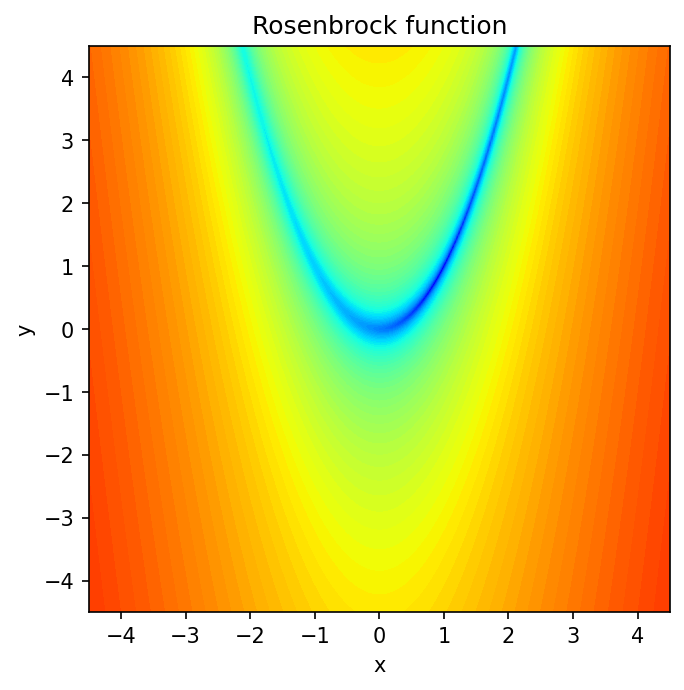

In [12]:
plot_path(None,f,'Rosenbrock function')

In [267]:
%%time
x = np.array([1.2,1.2])
path = [x]
tol = 1e-8
beta = 0.06 
alpha = 0.002                                     
max_steps = 20000
dx = Df(x[0],x[1])
pk = dx*0      # first update is just gradient descent
i=0
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -alpha*dx + beta*pk
    xnew = x + pk
    x = xnew
    i += 1
    dx = Df(x[0],x[1])
print(f'After {i} iterations, approximate minimum is {f(x[0],x[1])} at {x}')

After 12437 iterations, approximate minimum is 1.2518579045675558e-16 at [1.00000001 1.00000002]
CPU times: user 149 ms, sys: 20.9 ms, total: 170 ms
Wall time: 147 ms


### Question 2

a) Compute optimal solution by solving normal equation

In [454]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

data = np.loadtxt("CaCovidInfMarch24toMidJuly.txt")
Xcovid = np.arange(1, len(data) + 1)
linear = LinearRegression()

In [455]:
X_train = Xcovid[0:90].reshape(-1,1)
X_valid = Xcovid[90:120].reshape(-1,1)
y_train = data[0:90]
y_valid = data[90:120]

In [456]:
linear.fit(X_train,y_train)

LinearRegression()

In [457]:
y_predict = linear.predict(X_valid.reshape(-1,1))
y_predict

array([3358.83673473, 3389.00733134, 3419.17792795, 3449.34852455,
       3479.51912116, 3509.68971777, 3539.86031438, 3570.03091099,
       3600.2015076 , 3630.37210421, 3660.54270082, 3690.71329743,
       3720.88389404, 3751.05449065, 3781.22508726, 3811.39568387,
       3841.56628048, 3871.73687709, 3901.9074737 , 3932.0780703 ,
       3962.24866691, 3992.41926352, 4022.58986013, 4052.76045674,
       4082.93105335, 4113.10164996, 4143.27224657, 4173.44284318,
       4203.61343979, 4233.7840364 ])

In [458]:
print(np.sqrt(mean_squared_error(y_train, linear.predict(X_train.reshape(-1,1)))))
print(np.sqrt(mean_squared_error(y_valid, y_predict)))

417.8948376599642
4263.1047860409435


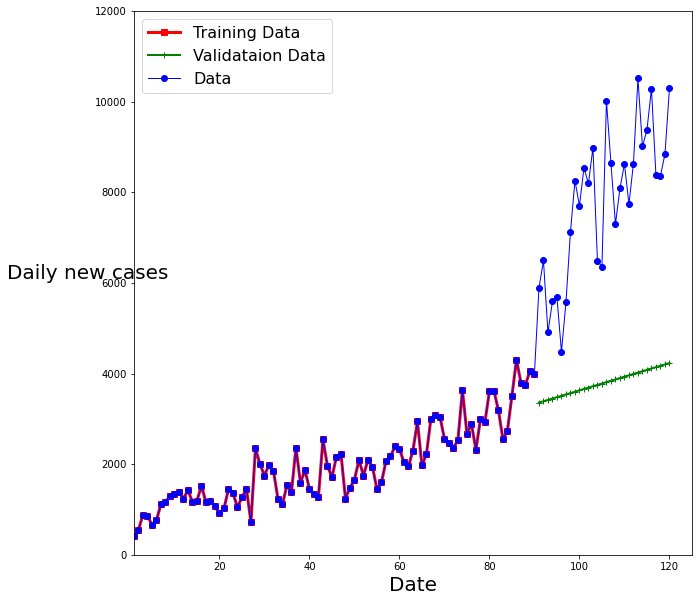

In [459]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

b) compute optimal solution by full batch gradient descent

In [487]:
def gradient_descent(X_b, y, n_iterations, eta=0.0000001):
    theta_path_bgd = []
    theta = np.random.randn(2,1) #random start
    for iteration in range(n_iterations):
        gradients = (1/len(X_b))*X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        theta_path_bgd.append(theta)
    return theta_path_bgd

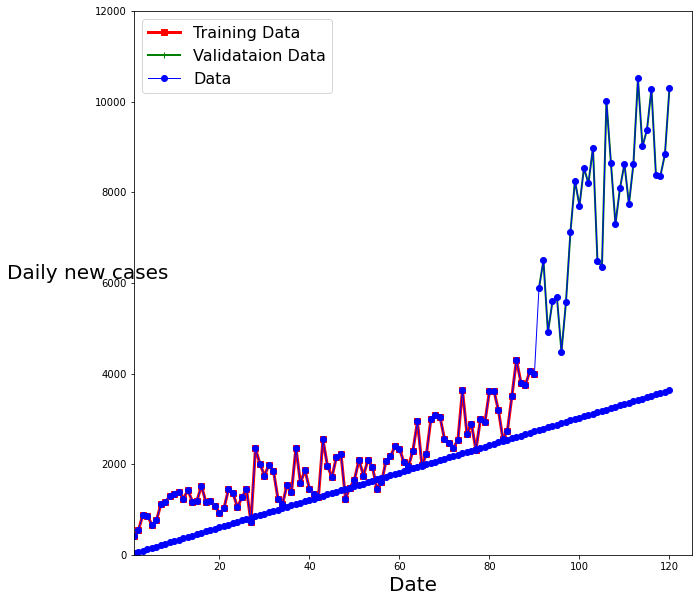

In [504]:
A = np.c_[np.ones((90, 1)), X_train]
data2 = np.reshape(y_train,(len(y_train),1))
theta_path = gradient_descent(A,data2,5000)
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_valid, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.plot(Xcovid,theta_path[-1][0]+theta_path[-1][1]*Xcovid, "b-o")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [502]:
y_predict1 = theta_path[-1][0]+theta_path[-1][1]*X_valid
print(np.sqrt(mean_squared_error(y_valid, y_predict1)))

4878.95249834953


c) compute optimal solution by mini-batch (size 10) stochastic gradient descent

In [687]:
def minibatch_gradient_descent(X_b, y, n_iterations, minibatch_size, t0=200, t1=500):
    eta=0.0000001
    m = len(X_b)
    theta = np.random.randn(2,1) # random initialization
    def learning_schedule(t): # Learning rate
        return t0 / (t + t1)
    t = 0
    for epoch in range(n_iterations):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        for i in range(0, m, minibatch_size):
            t += 1
            xi = X_b_shuffled[i:i+minibatch_size]
            yi = y_shuffled[i:i+minibatch_size]
            gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - eta * gradients
            theta_path_mgd.append(theta)
    return theta_path_mgd

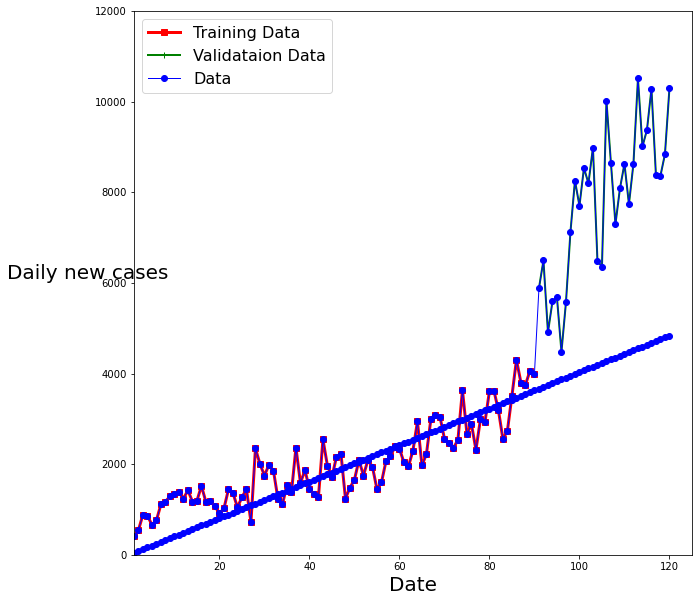

In [688]:
A = np.c_[np.ones((90, 1)), X_train]
data2 = np.reshape(y_train,(len(y_train),1))
theta_mini_path = minibatch_gradient_descent(A,data2,5000,10)
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_valid, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.plot(Xcovid,theta_mini_path[-1][0]+theta_mini_path[-1][1]*Xcovid, "b-o")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [689]:
y_predict2 = theta_mini_path[-1][0]+theta_mini_path[-1][1]*X_valid
print(np.sqrt(mean_squared_error(y_valid, y_predict2)))

3813.3989524010094


### Question 3

Repeat Problem 2 for quadratic polynomial regressionmodel.

In [690]:
quadratic = PolynomialFeatures(degree = 2)
X_quadratic = quadratic.fit_transform(Xcovid.reshape(-1,1))
X_train1 = X_quadratic[0:90]
X_valid1 = X_quadratic[90:120]
y_train = data[0:90]
y_valid = data[90:120]

In [691]:
polybig_features = PolynomialFeatures(degree=2,include_bias=False)
std_scaler = StandardScaler()
lin_reg = LinearRegression()
polynomial_regression = Pipeline([
("poly_features", polybig_features),
("std_scaler", std_scaler),
("lin_reg", lin_reg),
])

In [692]:
polynomial_regression.fit(X_train1, y_train)
y_predict4 = polynomial_regression.predict(X_valid1)
y_predict4

array([4028.9770682 , 4116.17866037, 4205.01872416, 4295.48007132,
       4387.54400669, 4481.1903282 , 4576.3973269 , 4673.14178695,
       4771.3989856 , 4871.14269319, 4972.34517318, 5074.97718214,
       5179.00796973, 5284.4052787 , 5391.13534493, 5499.16289739,
       5608.45115814, 5718.96184235, 5830.65515832, 5943.48980741,
       6057.42298411, 6172.41037599, 6288.40616376, 6405.36302119,
       6523.23211517, 6641.96310571, 6761.5041459 , 6881.80188193,
       7002.80145311, 7124.44649185])

In [693]:
print(np.sqrt(mean_squared_error(y_valid1, y_predict4)))

2564.3061565493117


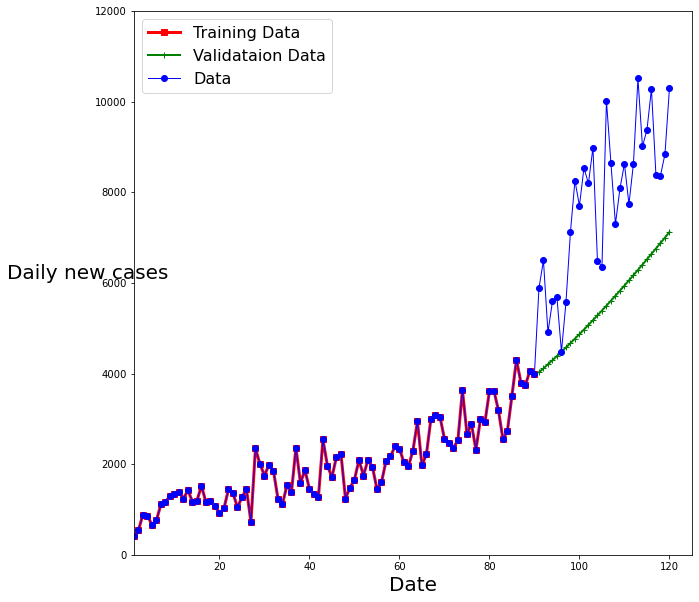

In [694]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict4, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [695]:
def gradient_descent(X_b, y, n_iterations, eta=0.0000001):
    theta_path_bgd = []
    theta = np.random.randn(3,1) #random start
    for iteration in range(n_iterations):
        gradients = (1/len(X_b))*X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        theta_path_bgd.append(theta)
    return theta_path_bgd

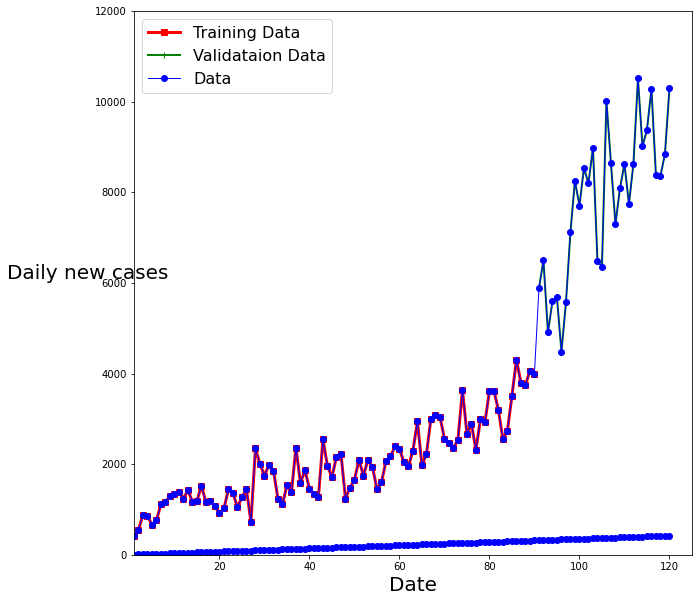

In [696]:
data2 = np.reshape(y_train,(len(y_train1),1))
theta_path = gradient_descent(X_train1,data2,5000)
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_valid, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.plot(Xcovid,theta_path[-1][0]+theta_path[-1][1]*Xcovid, "b-o")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [697]:
y_predict5 = theta_path[-1][0]+theta_path[-1][1]*X_valid
print(np.sqrt(mean_squared_error(y_valid1, y_predict3)))

7527.1851362845655


In [714]:
def minibatch_gradient_descent(X_b, y, n_iterations, minibatch_size, t0=200, t1=10000000000):
    m = len(X_b)
    theta = np.random.randn(3,1)
    
    def learning_schedule(t): # Learning rate
        return t0 / (t + t1)
    t=1
    for epoch in range(n_iterations):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        for i in range(0, m, minibatch_size):
            t += 1
            xi = X_b_shuffled[i:i+minibatch_size]
            yi = y_shuffled[i:i+minibatch_size]
            gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
            eta = learning_schedule(t)
            theta = theta - eta * gradients
            theta_path_mgd.append(theta)
    return theta_path_mgd

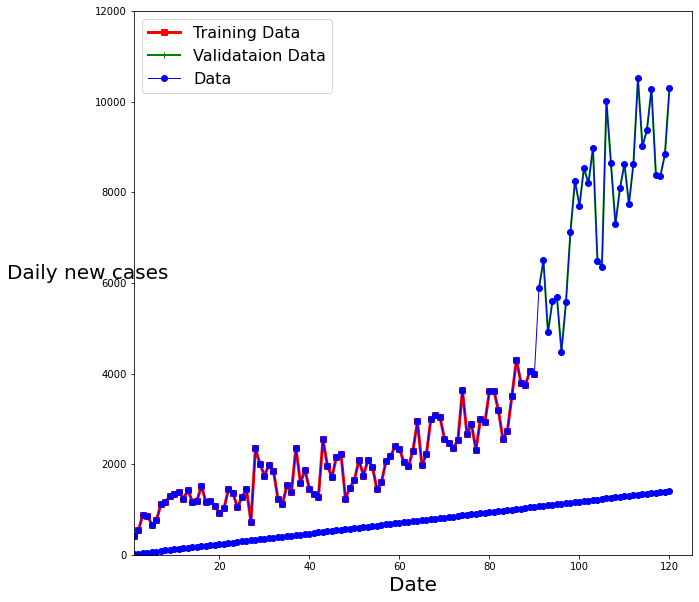

In [715]:
data2 = np.reshape(y_train,(len(y_train),1))
theta_mini_path = minibatch_gradient_descent(X_train1,data2,5000,10)
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_valid, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.plot(Xcovid,theta_mini_path[-1][0]+theta_mini_path[-1][1]*Xcovid, "b-o")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [716]:
y_predict6 = theta_mini_path[-1][0]+theta_mini_path[-1][1]*X_valid
print(np.sqrt(mean_squared_error(y_valid, y_predict6)))

6754.53885020073


### Question 4

Repeat Problem 2 for the cubic polynomial regression model

In [717]:
cube = PolynomialFeatures(degree = 3)
X_cube = cube.fit_transform(Xcovid.reshape(-1,1))
X_train2 = X_cube[0:90]
X_valid2 = X_cube[90:120]
y_train = data[0:90]
y_valid = data[90:120]

In [718]:
polynomial_regression.fit(X_train2, y_train)
y_predict7 = polynomial_regression.predict(X_valid2)
y_predict7

array([ 4175.06693096,  4311.30451336,  4456.84217935,  4612.35042247,
        4778.53389037,  4956.13230862,  5145.92141113,  5348.71387716,
        5565.36027503,  5796.7500123 ,  6043.81229266,  6307.51707944,
        6588.87606562,  6888.94365059,  7208.81792343,  7549.64165279,
        7912.60328346,  8298.93793949,  8709.9284339 ,  9146.90628507,
        9611.25273969, 10104.39980232, 10627.83127158, 11183.08378293,
       11771.74785811, 12395.46896108, 13055.9485607 , 13754.94519995,
       14494.27557175, 15275.81560141])

In [759]:
print(np.sqrt(mean_squared_error(y_valid, y_predict7)))

2429.6466082021316


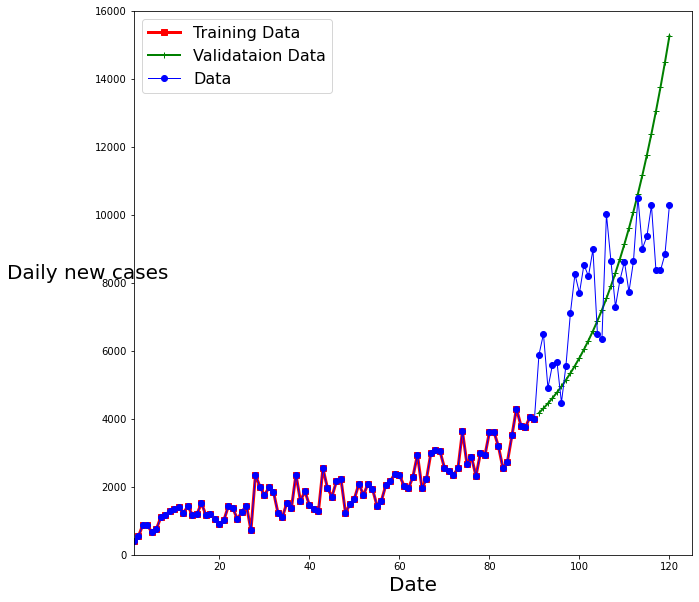

In [720]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict7, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 16000])
plt.show()

In [766]:
def gradient_descent(X_b, y, n_iterations, eta=0.00000000001):
    theta_path_bgd = []
    theta = np.random.randn(4,1) #random start
    for iteration in range(n_iterations):
        gradients = (1/len(X_b))*X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        theta_path_bgd.append(theta)
    return theta_path_bgd

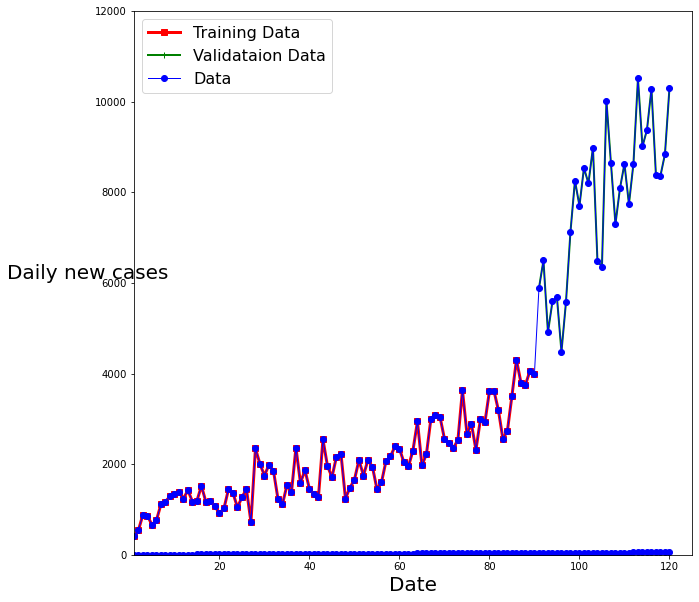

In [767]:
data2 = np.reshape(y_train,(len(y_train),1))
theta_path = gradient_descent(X_train2,data2,5000)
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_valid, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.plot(Xcovid,theta_path[-1][0]+theta_path[-1][1]*Xcovid, "b-o")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [768]:
y_predict8 = theta_path[-1][0]+theta_path[-1][1]*X_valid
print(np.sqrt(mean_squared_error(y_valid, y_predict8)))

7931.809121708734


In [774]:
def minibatch_gradient_descent(X_b, y, n_iterations, minibatch_size, t0=10, t1=1000000000000):
    m = len(X_b)
    theta = np.random.randn(4,1)
    
    def learning_schedule(t): # Learning rate
        return t0 / (t + t1)
    t=1
    for epoch in range(n_iterations):
        shuffled_indices = np.random.permutation(m)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        for i in range(0, m, minibatch_size):
            t += 1
            xi = X_b_shuffled[i:i+minibatch_size]
            yi = y_shuffled[i:i+minibatch_size]
            gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta) - yi)
            eta = learning_schedule(t)
            theta = theta - eta * gradients
            theta_path_mgd.append(theta)
    return theta_path_mgd

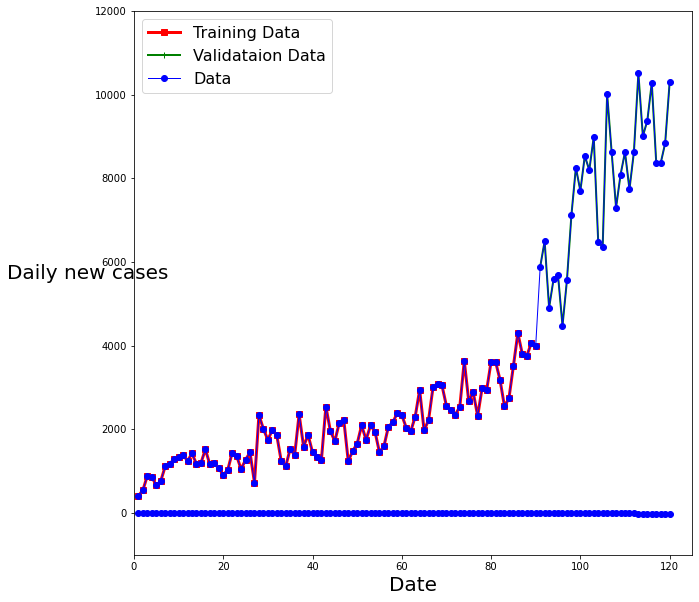

In [775]:
data2 = np.reshape(y_train,(len(y_train),1))
theta_mini_path = minibatch_gradient_descent(X_train2,data2,5000,10)
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_valid, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.plot(Xcovid,theta_mini_path[-1][0]+theta_mini_path[-1][1]*Xcovid, "b-o")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([0, 125, -1000, 12000])
plt.show()

In [771]:
y_predict9 = theta_mini_path[-1][0]+theta_mini_path[-1][1]*X_valid
print(np.sqrt(mean_squared_error(y_valid, y_predict9)))

8117.832190532143


### Question 5

Most of the models are not reliable to be used to predict the daily new casses of Covid-19 for California, base on datas from March to July 2021. A simple answer I could think of is that we can't predict new cases simply based on the record of old cases, we can see the increasing trend, but it is affected contributed by many external factors. 


From these graph, the most reliable one is probably the cube polynomial regression by solving normal equation, by increasing the degree of polynomials, the model seems to predict the increasing trend better. 


For full batch and mini-batch stochastic gradient descent, it seems like using linear polynomial would result in a better prediction. 